# Phase 1: three Ta pads + IDC + Al + JJ fingers from the DXF

Env: `chip`. Full typed steps: `devnotes/phase1.md`.

We are not using `MetalGUI`. The Metal layout is still there: `qm.view(design)` draws the qgeometry with matplotlib and that figure is what you look at in this notebook (and `out/phase1_metal.png`).

Islands are L6+L7 plus L2D2100 Al (meander cut at y = 0) plus L2D2400 JJ fingers. The 0.2 um JJ gaps stay open. L3 stays out.

Why the fingers were omitted at first, and why \(C_J \approx 56\) fF is those gaps: `devnotes/QuantroTa_01_layout_notes.md` (section "What \(C_J \approx 56\) fF actually is").

Install once: `pip install -e ".[dev]"` in conda env `chip`. Then `import quantromon` works from any cwd.

In [2]:
from quantromon.paths import outdir, repo_root

OUT = outdir(repo_root() / "out")
print("out", OUT)

cwd  /home/hm/QpiAi/Github/device_design/quantromon
root /home/hm/QpiAi/Github/device_design/quantromon


name     area_um2      cx_um      cy_um       xmin       ymin       xmax       ymax  holes
P1      244554.19      19.41     523.12    -125.00    -145.00     343.64    1021.00      0
P2      106716.64    -330.66       0.00    -550.00    -125.00     -63.50     125.00      0
P3      244704.19      20.27    -522.89    -125.00   -1021.00     353.64     145.00      0



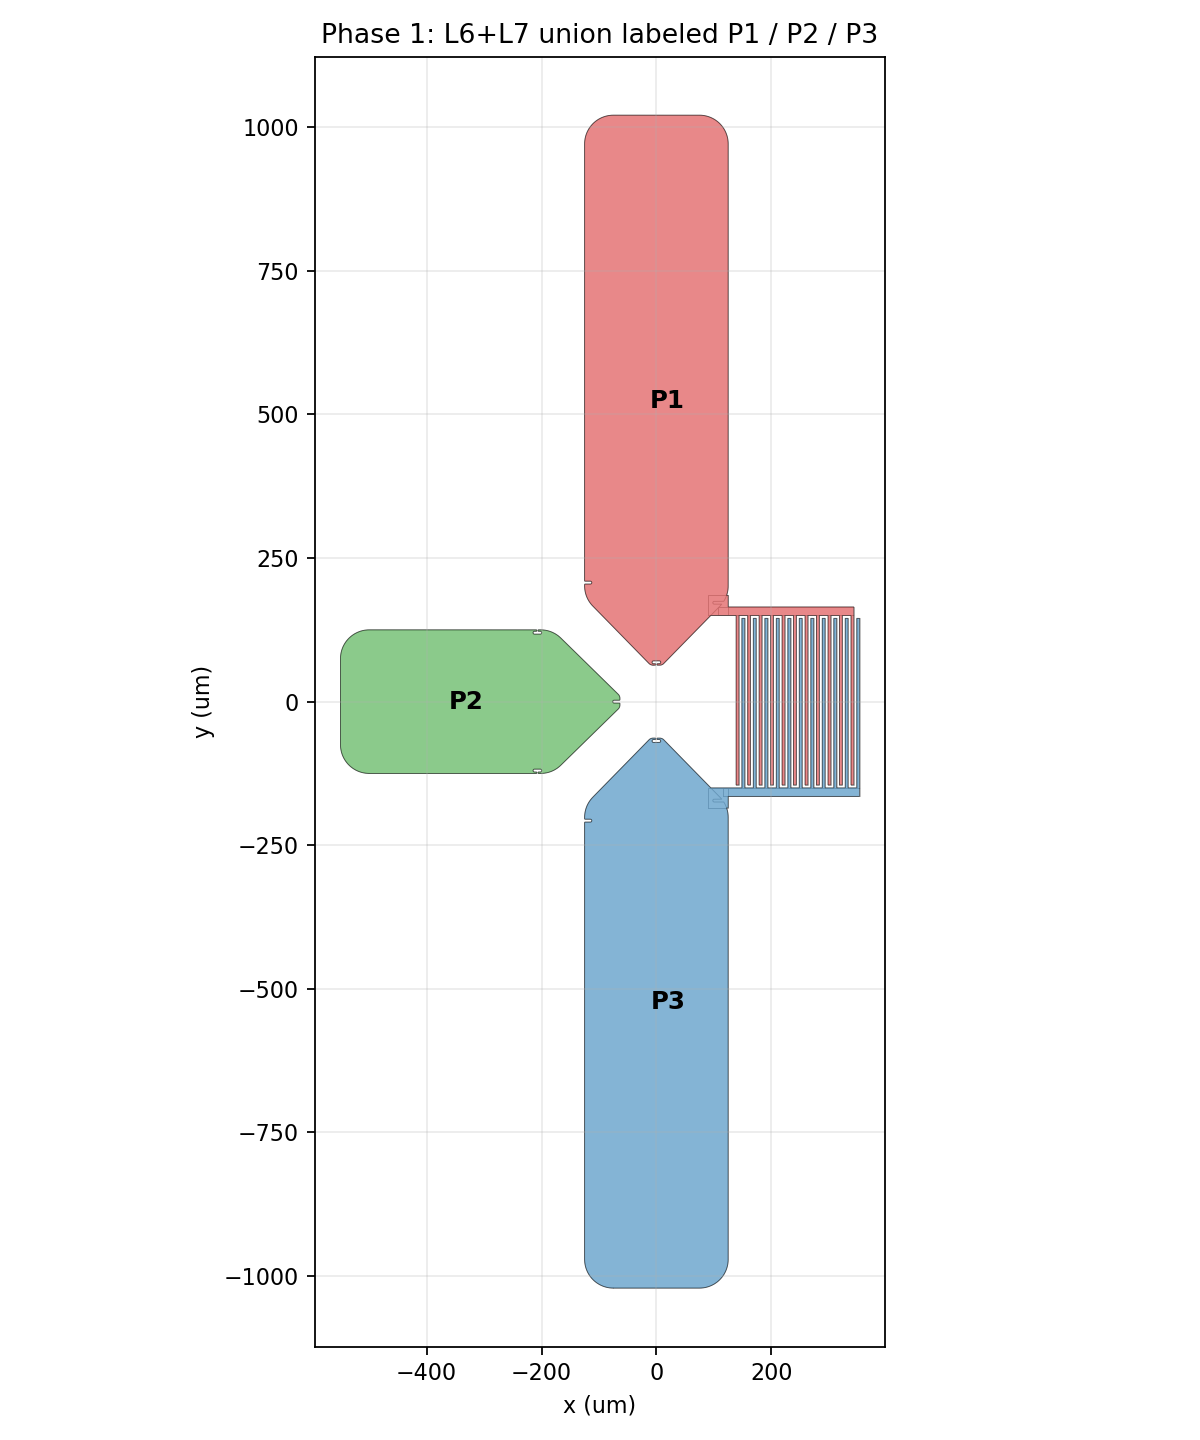

In [6]:
from IPython.display import Image, display
from quantromon.geometry.dxf import load_pad_islands, island_table, plot_islands, DEFAULT_DXF

islands = load_pad_islands(units="um")
print(island_table(islands))
png = plot_islands(islands, OUT / "phase1_islands.png", dxf_path=DEFAULT_DXF)
display(Image(filename=str(png)))

components: ['P1', 'P2', 'P3']
  P1: bounds mm (-0.1250,-0.1450)-(0.3436,1.0210)
  P2: bounds mm (-0.5500,-0.1250)-(-0.0635,0.1250)
  P3: bounds mm (-0.1250,-1.0210)-(0.3536,0.1450)


03:27PM 28s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/home/hm/QpiAi/Github/device_design/resources".


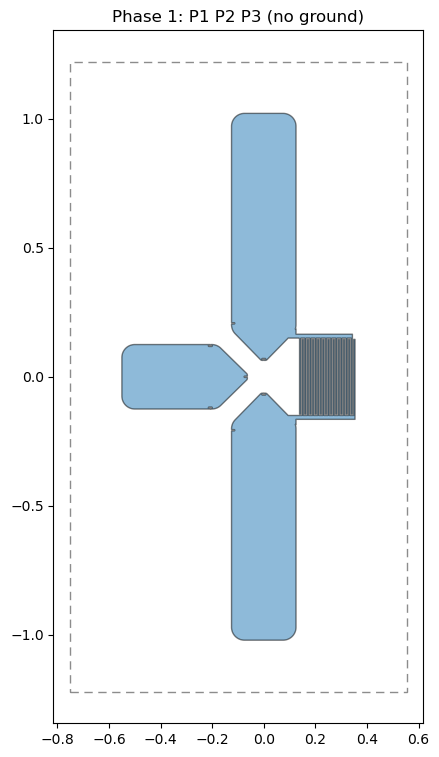

In [5]:
%matplotlib inline
import qiskit_metal as qm
from quantromon.geometry.pads import make_design, export_gds

design = make_design()
print("components:", list(design.components))
for name, comp in design.components.items():
    b = comp.qgeometry_bounds()
    print(f"  {name}: bounds mm ({b[0]:.4f},{b[1]:.4f})-({b[2]:.4f},{b[3]:.4f})")

# This is the Metal view: same geometry as MetalGUI, drawn with matplotlib.
fig = qm.view(design, figsize=(7.5, 9.0), title="Phase 1: P1 P2 P3 (no ground)")
fig.savefig(OUT / "phase1_metal.png", dpi=160, bbox_inches="tight")
export_gds(design, str(OUT / "phase1_pads.gds"))
fig